In [4]:
# import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [5]:
# load dataset

df = pd.read_csv("Bitcoin Historical Data (1).csv")
df

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,22-07-2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,21-07-2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,20-07-2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,19-07-2010,0.1,0.1,0.1,0.1,0.57K,0.00%


In [6]:
# change date format

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df = df.sort_values(by="Date", ascending=True)
df

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


In [7]:
# check info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 4998 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[us]
 1   Price     4999 non-null   str           
 2   Open      4999 non-null   str           
 3   High      4999 non-null   str           
 4   Low       4999 non-null   str           
 5   Vol.      4993 non-null   str           
 6   Change %  4999 non-null   str           
dtypes: datetime64[us](1), str(6)
memory usage: 451.5 KB


In [8]:
# clean price column

# Clean Close Price column
df['Price'] = df['Price'].astype(str).str.replace(',', '')
df['Price'] = df['Price'].replace('-', np.nan).astype(float)
df['Price'] = df['Price'].interpolate(method='linear')   

In [9]:
# scale price and preprocessing

scaler = MinMaxScaler()
scaled_price = scaler.fit_transform(df[['Price']])


In [12]:
# sliding window

# Ensure scaled_price has shape (n,1)
scaled_price = scaled_price.reshape(-1,1)

seq_length = 60
X, y = [], []

for i in range(len(scaled_price) - seq_length - 7):
    X.append(scaled_price[i:i+seq_length])   # shape (60,1)
    y.append([
        scaled_price[i+seq_length],       # 1 day ahead
        scaled_price[i+seq_length+3],     # 3 days ahead
        scaled_price[i+seq_length+7]      # 7 days ahead
    ])

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)  # (samples, 60, 1)
print("y shape:", y.shape)  # (samples, 3, 1)


X shape: (4932, 60, 1)
y shape: (4932, 3, 1)


In [13]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3945, 60, 1)
Test shape: (987, 60, 1)


In [ ]:
X_test[0].shape

(60, 1)

In [14]:
# build and compile model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(seq_length,1)))
lstm_model.add(Dense(3))          # 3 horizons × 1 feature
lstm_model.add(Reshape((3,1)))    # reshape to (3,1)

lstm_model.compile(loss="mse", optimizer="adam")
lstm_model.summary()


e:\vscode\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,091 (66.76 KB)

 Trainable params: 17,091 (66.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train the model

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_split=0.1,
    verbose=1
)



Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 2.9926e-04 - val_loss: 0.0060
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.6387e-05 - val_loss: 0.0107
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 6.8585e-05 - val_loss: 0.0092
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 6.4133e-05 - val_loss: 0.0076
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 6.0016e-05 - val_loss: 0.0096
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 6.0951e-05 - val_loss: 0.0111
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 5.8037e-05 - val_loss: 0.0114
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 5.4701e-05 - val_loss: 0.0081
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 5.7726e-05 - val_loss: 0.0096
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 5.3124e-05 - val_loss: 0.0106
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5.0814e-05 - val_loss: 0.01

In [16]:
# predict 

y_pred_lstm = lstm_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [17]:
# save metrics and print results

mae_lstm_1 = mean_absolute_error(y_test[:,0,0], y_pred_lstm[:,0,0])
rmse_lstm_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_lstm[:,0,0]))
mape_lstm_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_lstm[:,0,0])

mae_lstm_3 = mean_absolute_error(y_test[:,1,0], y_pred_lstm[:,1,0])
rmse_lstm_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_lstm[:,1,0]))
mape_lstm_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_lstm[:,1,0])

mae_lstm_7 = mean_absolute_error(y_test[:,2,0], y_pred_lstm[:,2,0])
rmse_lstm_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_lstm[:,2,0]))
mape_lstm_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_lstm[:,2,0])

print(f"LSTM 1-Day -> MAE: {mae_lstm_1:.4f}, RMSE: {rmse_lstm_1:.4f}, MAPE: {mape_lstm_1:.2f}%")
print(f"LSTM 3-Day -> MAE: {mae_lstm_3:.4f}, RMSE: {rmse_lstm_3:.4f}, MAPE: {mape_lstm_3:.2f}%")
print(f"LSTM 7-Day -> MAE: {mae_lstm_7:.4f}, RMSE: {rmse_lstm_7:.4f}, MAPE: {mape_lstm_7:.2f}%")

LSTM 1-Day -> MAE: 0.0268, RMSE: 0.0358, MAPE: 0.05%
LSTM 3-Day -> MAE: 0.0845, RMSE: 0.1059, MAPE: 0.16%
LSTM 7-Day -> MAE: 0.1593, RMSE: 0.1932, MAPE: 0.30%


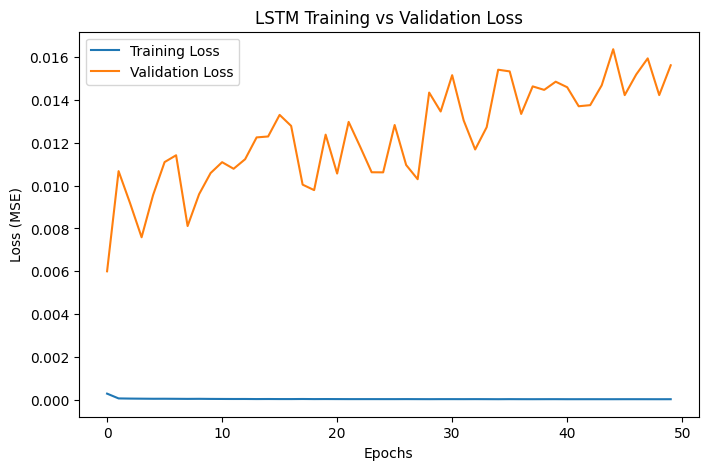

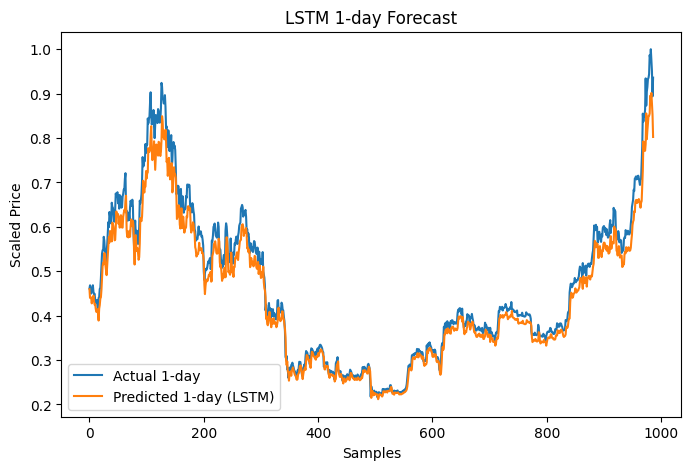

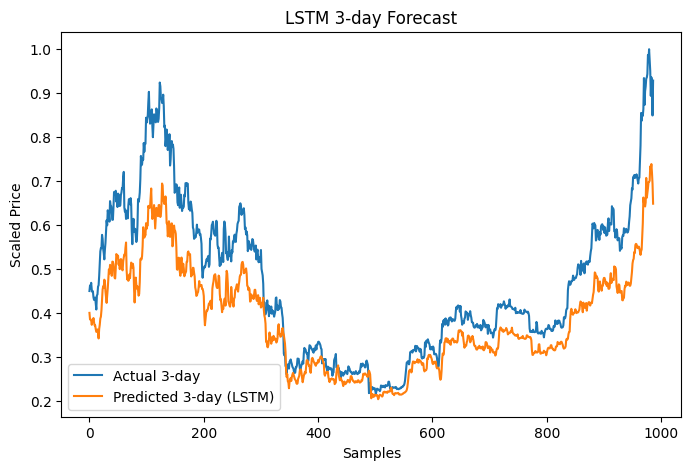

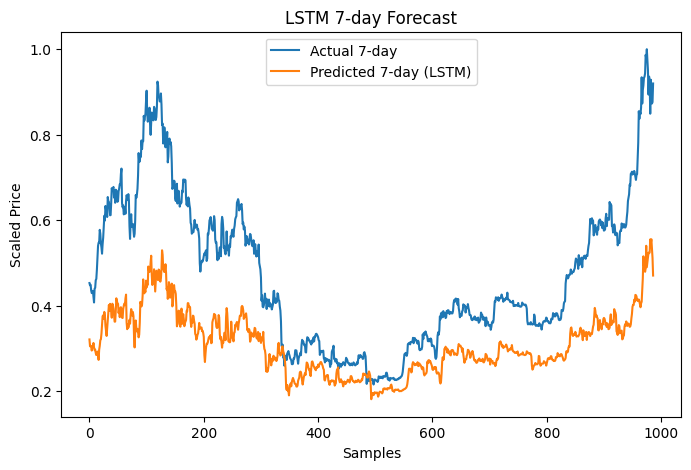

In [18]:
import matplotlib.pyplot as plt

# Visualisations
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

for i, horizon in enumerate(["1-day","3-day","7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_lstm[:,i,0], label=f"Predicted {horizon} (LSTM)")
    plt.title(f"LSTM {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()


In [ ]:
## CNN model

In [20]:
# building model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Reshape

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length,1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(3))          # 3 horizons × 1 feature
cnn_model.add(Reshape((3,1)))    # reshape to (3,1)

cnn_model.compile(loss="mse", optimizer="adam")
cnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │        11,139 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,395 (44.51 KB)

 Trainable params: 11,395 (44.51 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# training the model

history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6480e-04 - val_loss: 0.0071
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.3294e-05 - val_loss: 0.0047
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.6751e-05 - val_loss: 0.0054
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7128e-05 - val_loss: 0.0040
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.5857e-05 - val_loss: 0.0051
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3560e-05 - val_loss: 0.0032
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.6628e-05 - val_loss: 0.0043
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5326e-05 - val_loss: 0.0039
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1668e-05 - val_loss: 0.0031
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.2387e-05 - val_loss: 0.0047
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.3411e-05 - val_loss: 0.0048
Epoch 12

In [22]:
# pedict cnn 

y_pred_cnn = cnn_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [23]:
# evaluate cnn metrics

mae_cnn_1 = mean_absolute_error(y_test[:,0,0], y_pred_cnn[:,0,0])
rmse_cnn_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_cnn[:,0,0]))
mape_cnn_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_cnn[:,0,0])

mae_cnn_3 = mean_absolute_error(y_test[:,1,0], y_pred_cnn[:,1,0])
rmse_cnn_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_cnn[:,1,0]))
mape_cnn_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_cnn[:,1,0])

mae_cnn_7 = mean_absolute_error(y_test[:,2,0], y_pred_cnn[:,2,0])
rmse_cnn_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_cnn[:,2,0]))
mape_cnn_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_cnn[:,2,0])

print(f"CNN 1-Day -> MAE: {mae_cnn_1:.4f}, RMSE: {rmse_cnn_1:.4f}, MAPE: {mape_cnn_1:.2f}%")
print(f"CNN 3-Day -> MAE: {mae_cnn_3:.4f}, RMSE: {rmse_cnn_3:.4f}, MAPE: {mape_cnn_3:.2f}%")
print(f"CNN 7-Day -> MAE: {mae_cnn_7:.4f}, RMSE: {rmse_cnn_7:.4f}, MAPE: {mape_cnn_7:.2f}%")




CNN 1-Day -> MAE: 0.0214, RMSE: 0.0308, MAPE: 0.04%
CNN 3-Day -> MAE: 0.0293, RMSE: 0.0407, MAPE: 0.06%
CNN 7-Day -> MAE: 0.0443, RMSE: 0.0586, MAPE: 0.10%


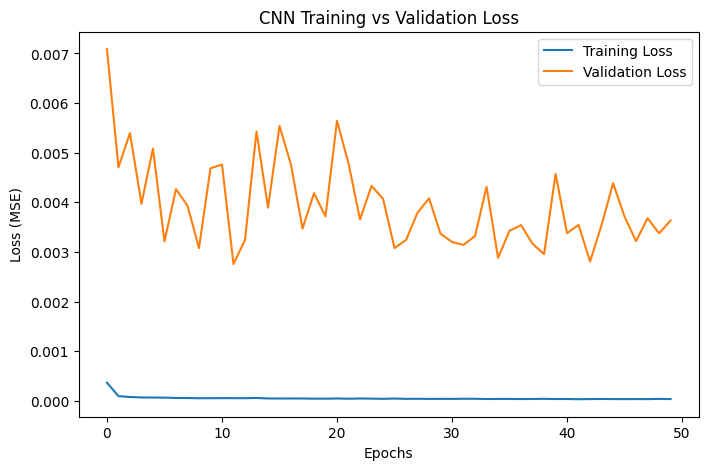

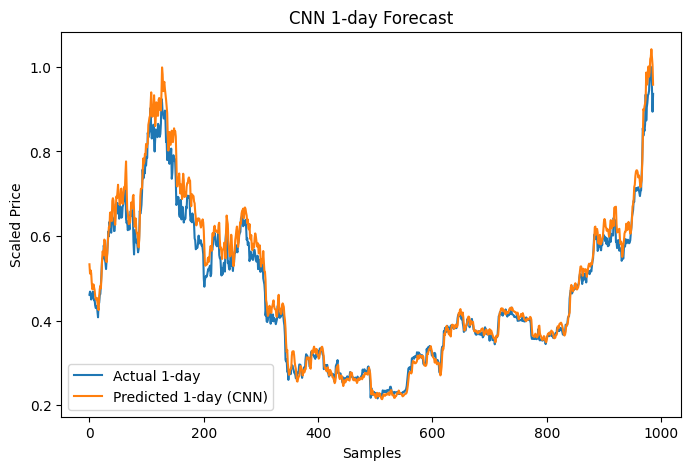

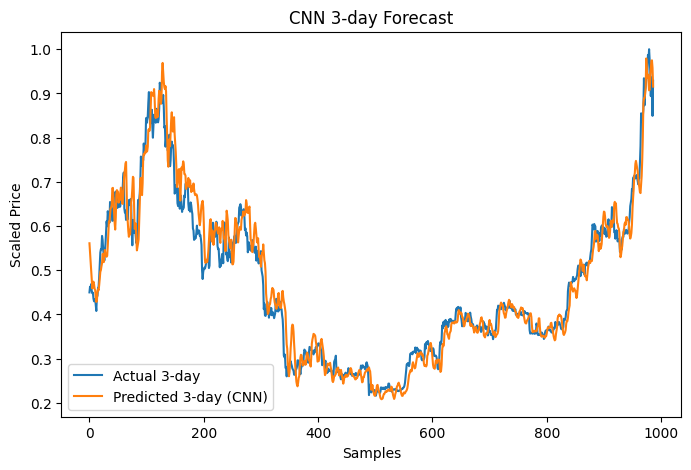

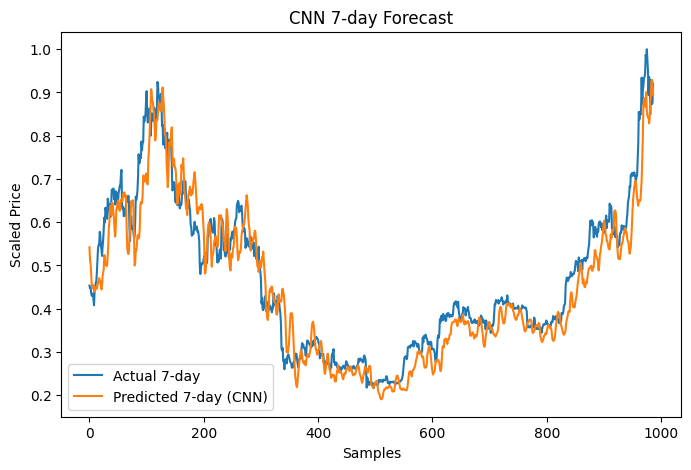

In [24]:
# visualisation

# Visualisations
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

for i, horizon in enumerate(["1-day","3-day","7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_cnn[:,i,0], label=f"Predicted {horizon} (CNN)")
    plt.title(f"CNN {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()

In [ ]:
# RNN

In [25]:
# building rnn model

from tensorflow.keras.layers import SimpleRNN

# Build RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64, input_shape=(seq_length,1)))
rnn_model.add(Dense(3))
rnn_model.add(Reshape((3,1)))

rnn_model.compile(loss="mse", optimizer="adam")
rnn_model.summary()

e:\vscode\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,419 (17.26 KB)

 Trainable params: 4,419 (17.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# train model

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.4210e-04 - val_loss: 0.0249
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.2537e-05 - val_loss: 0.0120
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.3771e-05 - val_loss: 0.0113
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.0303e-05 - val_loss: 0.0086
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5.9117e-05 - val_loss: 0.0077
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5.4518e-05 - val_loss: 0.0045
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1703e-05 - val_loss: 0.0049
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 5.5568e-05 - val_loss: 0.0052
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 4.8910e-05 - val_loss: 0.0032
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 4.9314e-05 - val_loss: 0.0031
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 4.8251e-05 - val_loss: 0.00

In [27]:
# predict rnn

y_pred_rnn = rnn_model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [28]:
# evaluate metrics

mae_rnn_1 = mean_absolute_error(y_test[:,0,0], y_pred_rnn[:,0,0])
rmse_rnn_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_rnn[:,0,0]))
mape_rnn_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_rnn[:,0,0])

mae_rnn_3 = mean_absolute_error(y_test[:,1,0], y_pred_rnn[:,1,0])
rmse_rnn_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_rnn[:,1,0]))
mape_rnn_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_rnn[:,1,0])

mae_rnn_7 = mean_absolute_error(y_test[:,2,0], y_pred_rnn[:,2,0])
rmse_rnn_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_rnn[:,2,0]))
mape_rnn_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_rnn[:,2,0])

print(f"RNN 1-Day -> MAE: {mae_rnn_1:.4f}, RMSE: {rmse_rnn_1:.4f}, MAPE: {mape_rnn_1:.2f}%")
print(f"RNN 3-Day -> MAE: {mae_rnn_3:.4f}, RMSE: {rmse_rnn_3:.4f}, MAPE: {mape_rnn_3:.2f}%")
print(f"RNN 7-Day -> MAE: {mae_rnn_7:.4f}, RMSE: {rmse_rnn_7:.4f}, MAPE: {mape_rnn_7:.2f}%")


RNN 1-Day -> MAE: 0.0122, RMSE: 0.0179, MAPE: 0.02%
RNN 3-Day -> MAE: 0.0257, RMSE: 0.0364, MAPE: 0.05%
RNN 7-Day -> MAE: 0.0334, RMSE: 0.0478, MAPE: 0.07%


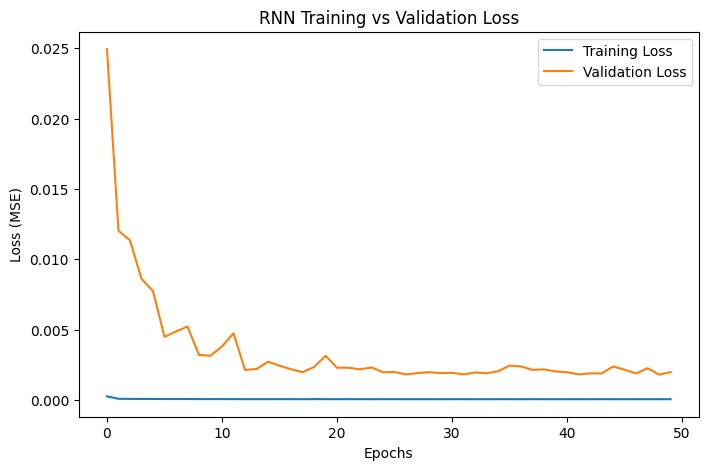

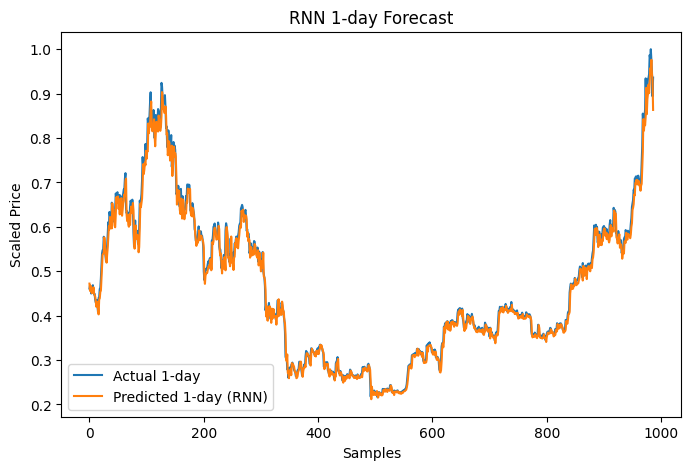

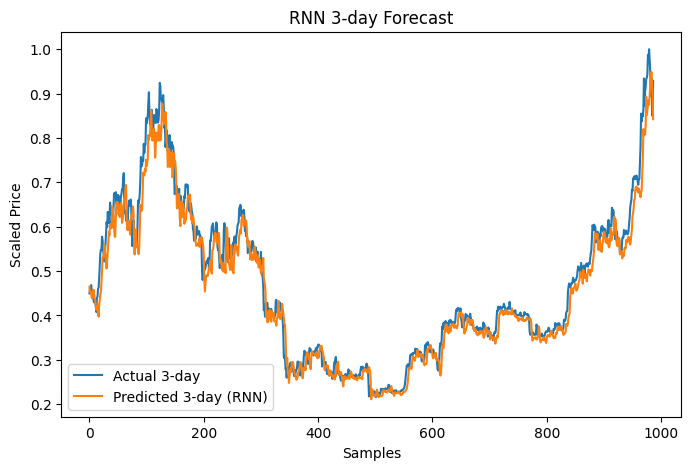

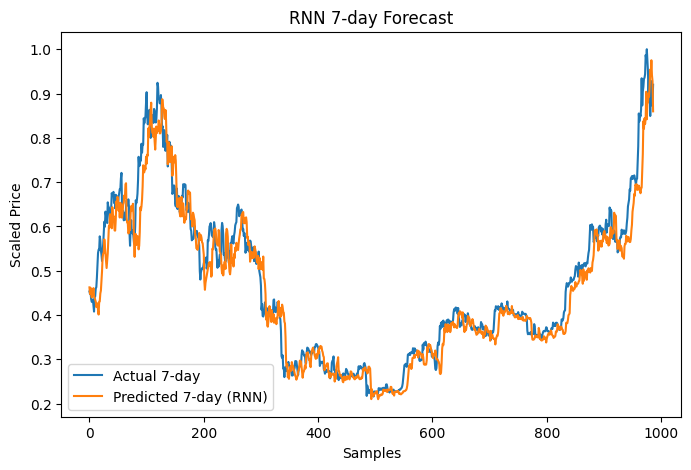

In [29]:
# visualization

# Visualisations
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

for i, horizon in enumerate(["1-day","3-day","7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_rnn[:,i,0], label=f"Predicted {horizon} (RNN)")
    plt.title(f"RNN {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()

In [ ]:
# Transformers

In [32]:
# build model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, MultiHeadAttention, LayerNormalization, Flatten, Dense, Reshape

# Build Transformer model
inputs = Input(shape=(seq_length,1))
attention = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
attention = LayerNormalization(epsilon=1e-6)(attention)

flat = Flatten()(attention)
dense = Dense(3)(flat)
outputs = Reshape((3,1))(dense)

transformer_model = Model(inputs=inputs, outputs=outputs)
transformer_model.compile(loss="mse", optimizer="adam")
transformer_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │        449 │ input_layer_5[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 60)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        183 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 3, 1)      │          0 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 634 (2.48 KB)

 Trainable params: 634 (2.48 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# train transformer

history_transformer = transformer_model.fit(
    X_train, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1
)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0026 - val_loss: 0.1859
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0025 - val_loss: 0.1826
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0025 - val_loss: 0.1884
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - val_loss: 0.1897
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0025 - val_loss: 0.1862
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.1891
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0025 - val_loss: 0.1864
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0025 - val_loss: 0.1879
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0025 - val_loss: 0.1884
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0025 - val_loss: 0.1863
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0025 - val_loss: 0.1872
Epoch 12/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2

In [34]:
# predict using transformer

y_pred_transformer = transformer_model.predict(X_test)



31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [35]:
# evaluate

mae_transformer_1 = mean_absolute_error(y_test[:,0,0], y_pred_transformer[:,0,0])
rmse_transformer_1 = np.sqrt(mean_squared_error(y_test[:,0,0], y_pred_transformer[:,0,0]))
mape_transformer_1 = mean_absolute_percentage_error(y_test[:,0,0], y_pred_transformer[:,0,0])

mae_transformer_3 = mean_absolute_error(y_test[:,1,0], y_pred_transformer[:,1,0])
rmse_transformer_3 = np.sqrt(mean_squared_error(y_test[:,1,0], y_pred_transformer[:,1,0]))
mape_transformer_3 = mean_absolute_percentage_error(y_test[:,1,0], y_pred_transformer[:,1,0])

mae_transformer_7 = mean_absolute_error(y_test[:,2,0], y_pred_transformer[:,2,0])
rmse_transformer_7 = np.sqrt(mean_squared_error(y_test[:,2,0], y_pred_transformer[:,2,0]))
mape_transformer_7 = mean_absolute_percentage_error(y_test[:,2,0], y_pred_transformer[:,2,0])

print(f"Transformer 1-Day -> MAE: {mae_transformer_1:.4f}, RMSE: {rmse_transformer_1:.4f}, MAPE: {mape_transformer_1:.2f}%")
print(f"Transformer 3-Day -> MAE: {mae_transformer_3:.4f}, RMSE: {rmse_transformer_3:.4f}, MAPE: {mape_transformer_3:.2f}%")
print(f"Transformer 7-Day -> MAE: {mae_transformer_7:.4f}, RMSE: {rmse_transformer_7:.4f}, MAPE: {mape_transformer_7:.2f}%")


Transformer 1-Day -> MAE: 0.4314, RMSE: 0.4652, MAPE: 0.91%
Transformer 3-Day -> MAE: 0.4324, RMSE: 0.4667, MAPE: 0.91%
Transformer 7-Day -> MAE: 0.4345, RMSE: 0.4694, MAPE: 0.92%


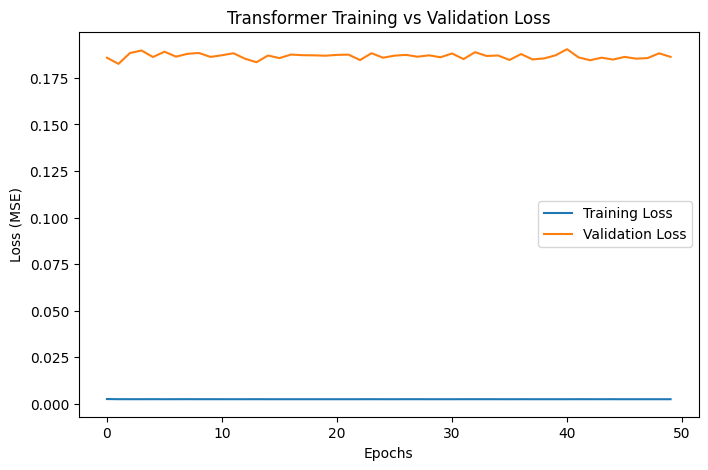

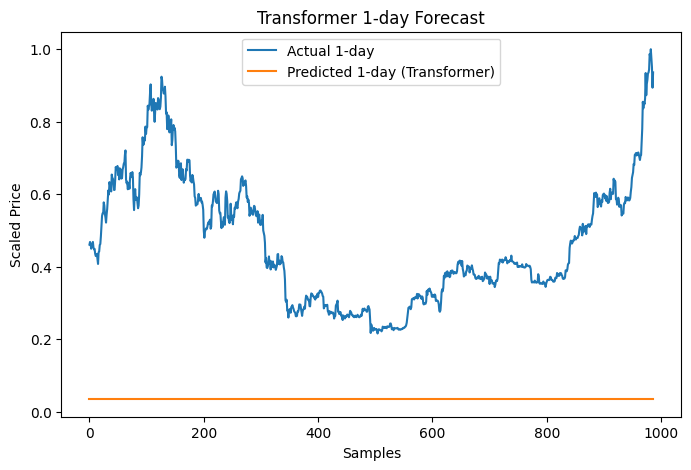

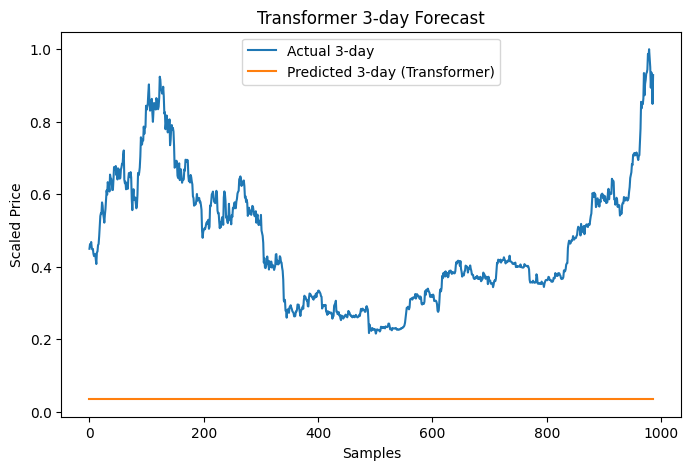

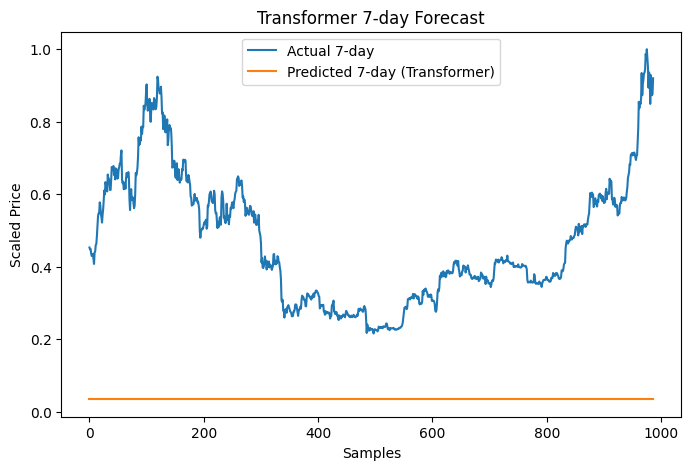

In [36]:
# Visualisations
plt.figure(figsize=(8,5))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

for i, horizon in enumerate(["1-day","3-day","7-day"]):
    plt.figure(figsize=(8,5))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_transformer[:,i,0], label=f"Predicted {horizon} (Transformer)")
    plt.title(f"Transformer {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()

In [37]:
# seeing all models side by side

import pandas as pd

# Collect results into a dictionary
results = {
    "Model": ["LSTM", "CNN", "RNN", "Transformer"],
    "1-Day MAE": [mae_lstm_1, mae_cnn_1, mae_rnn_1, mae_transformer_1],
    "1-Day RMSE": [rmse_lstm_1, rmse_cnn_1, rmse_rnn_1, rmse_transformer_1],
    "1-Day MAPE": [mape_lstm_1, mape_cnn_1, mape_rnn_1, mape_transformer_1],
    "3-Day MAE": [mae_lstm_3, mae_cnn_3, mae_rnn_3, mae_transformer_3],
    "3-Day RMSE": [rmse_lstm_3, rmse_cnn_3, rmse_rnn_3, rmse_transformer_3],
    "3-Day MAPE": [mape_lstm_3, mape_cnn_3, mape_rnn_3, mape_transformer_3],
    "7-Day MAE": [mae_lstm_7, mae_cnn_7, mae_rnn_7, mae_transformer_7],
    "7-Day RMSE": [rmse_lstm_7, rmse_cnn_7, rmse_rnn_7, rmse_transformer_7],
    "7-Day MAPE": [mape_lstm_7, mape_cnn_7, mape_rnn_7, mape_transformer_7],
}

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Display neatly
print(df_results)


         Model  1-Day MAE  1-Day RMSE  1-Day MAPE  3-Day MAE  3-Day RMSE  \
0         LSTM   0.026829    0.035777    0.050648   0.084533    0.105949   
1          CNN   0.021402    0.030798    0.042262   0.029307    0.040653   
2          RNN   0.012155    0.017886    0.024536   0.025698    0.036366   
3  Transformer   0.431422    0.465206    0.914867   0.432387    0.466720   

   3-Day MAPE  7-Day MAE  7-Day RMSE  7-Day MAPE  
0    0.158629   0.159274    0.193205    0.301247  
1    0.063543   0.044280    0.058622    0.095203  
2    0.051959   0.033422    0.047788    0.067909  
3    0.914089   0.434495    0.469449    0.915118  


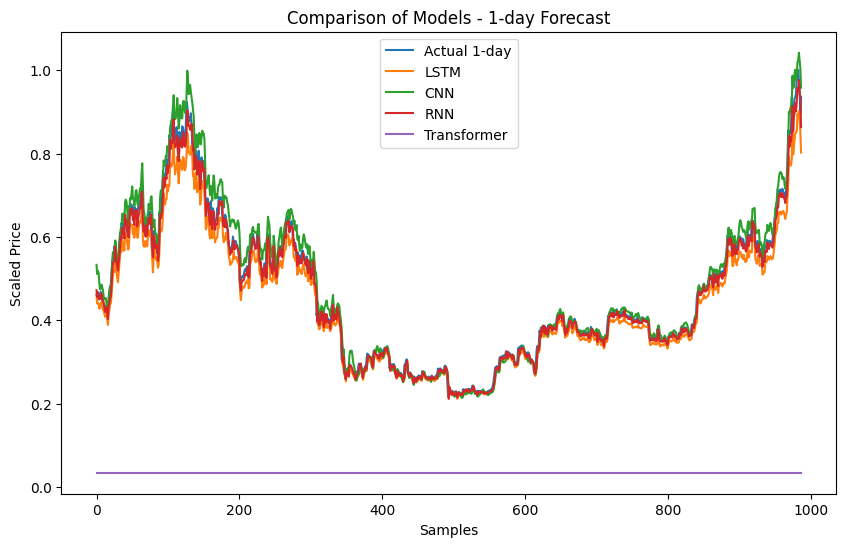

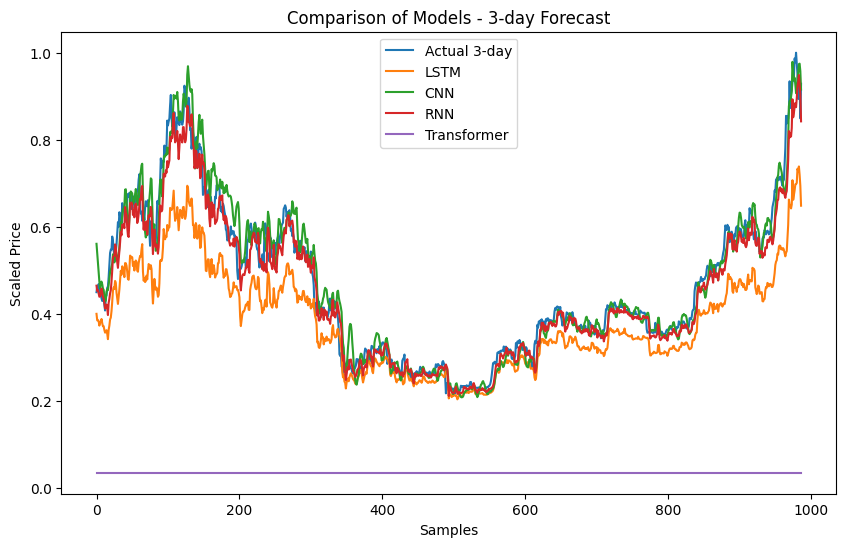

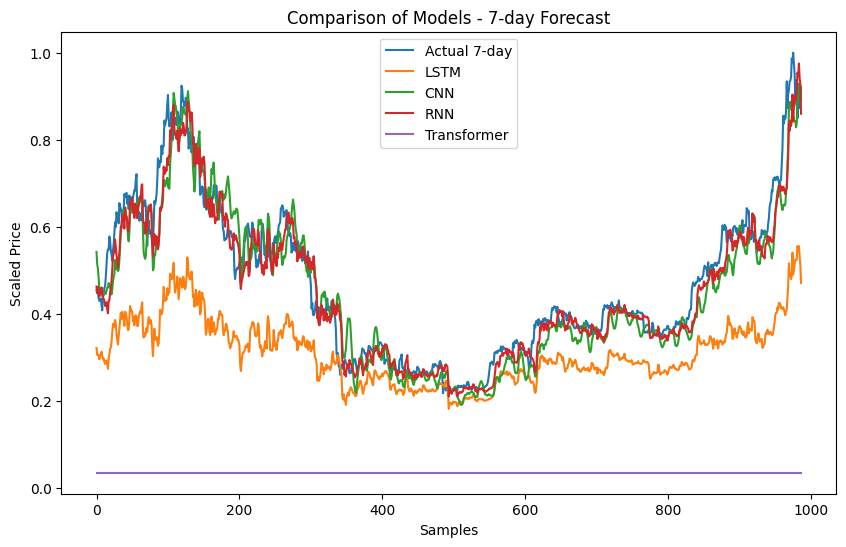

In [38]:
# combined visualisation

import matplotlib.pyplot as plt

# Combined visualisation for all models
for i, horizon in enumerate(["1-day", "3-day", "7-day"]):
    plt.figure(figsize=(10,6))
    plt.plot(y_test[:,i,0], label=f"Actual {horizon}")
    plt.plot(y_pred_lstm[:,i,0], label="LSTM")
    plt.plot(y_pred_cnn[:,i,0], label="CNN")
    plt.plot(y_pred_rnn[:,i,0], label="RNN")
    plt.plot(y_pred_transformer[:,i,0], label="Transformer")
    plt.title(f"Comparison of Models - {horizon} Forecast")
    plt.xlabel("Samples")
    plt.ylabel("Scaled Price")
    plt.legend()
    plt.show()


In [39]:
# Ranking models by lowest MAE for each horizon

for horizon in ["1-Day MAE", "3-Day MAE", "7-Day MAE"]:
    best_model = df_results.loc[df_results[horizon].idxmin(), "Model"]
    best_score = df_results[horizon].min()
    print(f"Best model for {horizon}: {best_model} (MAE={best_score:.4f})")


Best model for 1-Day MAE: RNN (MAE=0.0122)
Best model for 3-Day MAE: RNN (MAE=0.0257)
Best model for 7-Day MAE: RNN (MAE=0.0334)


In [40]:
# Highlighting the best model (lowest MAE) for each horizon

def highlight_best(s):
    is_min = s == s.min()
    return ['color: red; font-weight: bold' if v else '' for v in is_min]

df_results.style.apply(
    highlight_best,
    subset=["1-Day MAE", "3-Day MAE", "7-Day MAE"]
)


,Model,1-Day MAE,1-Day RMSE,1-Day MAPE,3-Day MAE,3-Day RMSE,3-Day MAPE,7-Day MAE,7-Day RMSE,7-Day MAPE
0,LSTM,0.026829,0.035777,0.050648,0.084533,0.105949,0.158629,0.159274,0.193205,0.301247
1,CNN,0.021402,0.030798,0.042262,0.029307,0.040653,0.063543,0.044280,0.058622,0.095203
2,RNN,0.012155,0.017886,0.024536,0.025698,0.036366,0.051959,0.033422,0.047788,0.067909
3,Transformer,0.431422,0.465206,0.914867,0.432387,0.466720,0.914089,0.434495,0.469449,0.915118


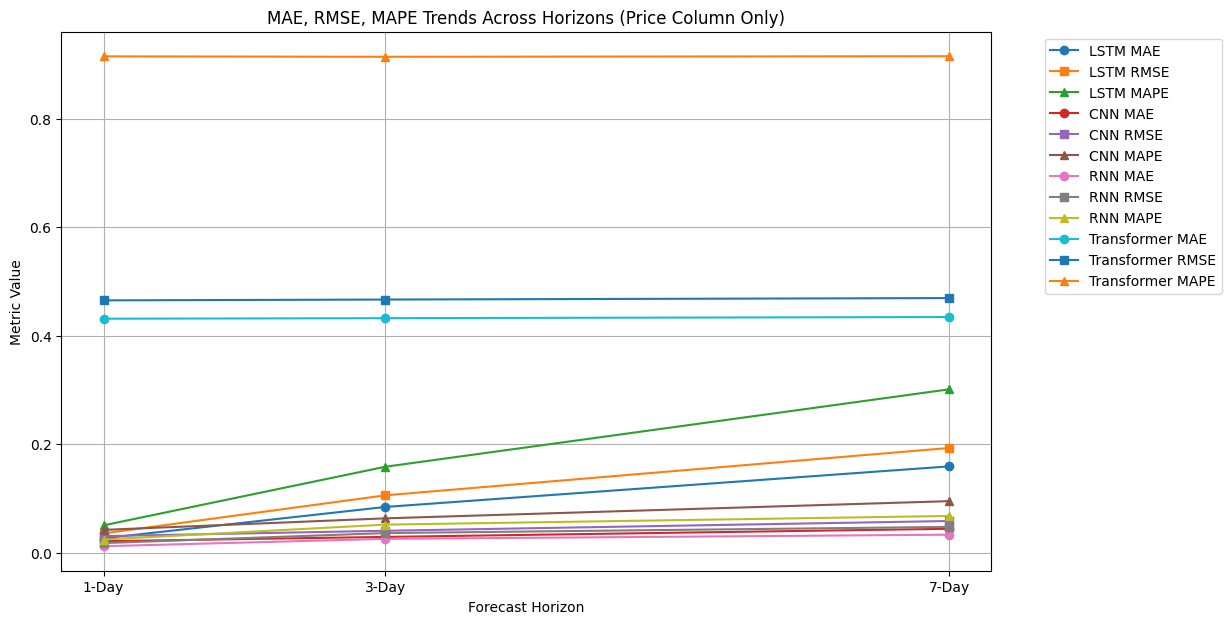

In [41]:
# Trend Line Chart

import matplotlib.pyplot as plt

# Horizons and x-axis values
horizons = ["1-Day", "3-Day", "7-Day"]
x = [1, 3, 7]

plt.figure(figsize=(12,7))

# LSTM metrics
plt.plot(x, [mae_lstm_1, mae_lstm_3, mae_lstm_7], marker='o', label="LSTM MAE")
plt.plot(x, [rmse_lstm_1, rmse_lstm_3, rmse_lstm_7], marker='s', label="LSTM RMSE")
plt.plot(x, [mape_lstm_1, mape_lstm_3, mape_lstm_7], marker='^', label="LSTM MAPE")

# CNN metrics
plt.plot(x, [mae_cnn_1, mae_cnn_3, mae_cnn_7], marker='o', label="CNN MAE")
plt.plot(x, [rmse_cnn_1, rmse_cnn_3, rmse_cnn_7], marker='s', label="CNN RMSE")
plt.plot(x, [mape_cnn_1, mape_cnn_3, mape_cnn_7], marker='^', label="CNN MAPE")

# RNN metrics
plt.plot(x, [mae_rnn_1, mae_rnn_3, mae_rnn_7], marker='o', label="RNN MAE")
plt.plot(x, [rmse_rnn_1, rmse_rnn_3, rmse_rnn_7], marker='s', label="RNN RMSE")
plt.plot(x, [mape_rnn_1, mape_rnn_3, mape_rnn_7], marker='^', label="RNN MAPE")

# Transformer metrics
plt.plot(x, [mae_transformer_1, mae_transformer_3, mae_transformer_7], marker='o', label="Transformer MAE")
plt.plot(x, [rmse_transformer_1, rmse_transformer_3, rmse_transformer_7], marker='s', label="Transformer RMSE")
plt.plot(x, [mape_transformer_1, mape_transformer_3, mape_transformer_7], marker='^', label="Transformer MAPE")

# Formatting
plt.xticks(x, horizons)
plt.title("MAE, RMSE, MAPE Trends Across Horizons (Price Column Only)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Metric Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


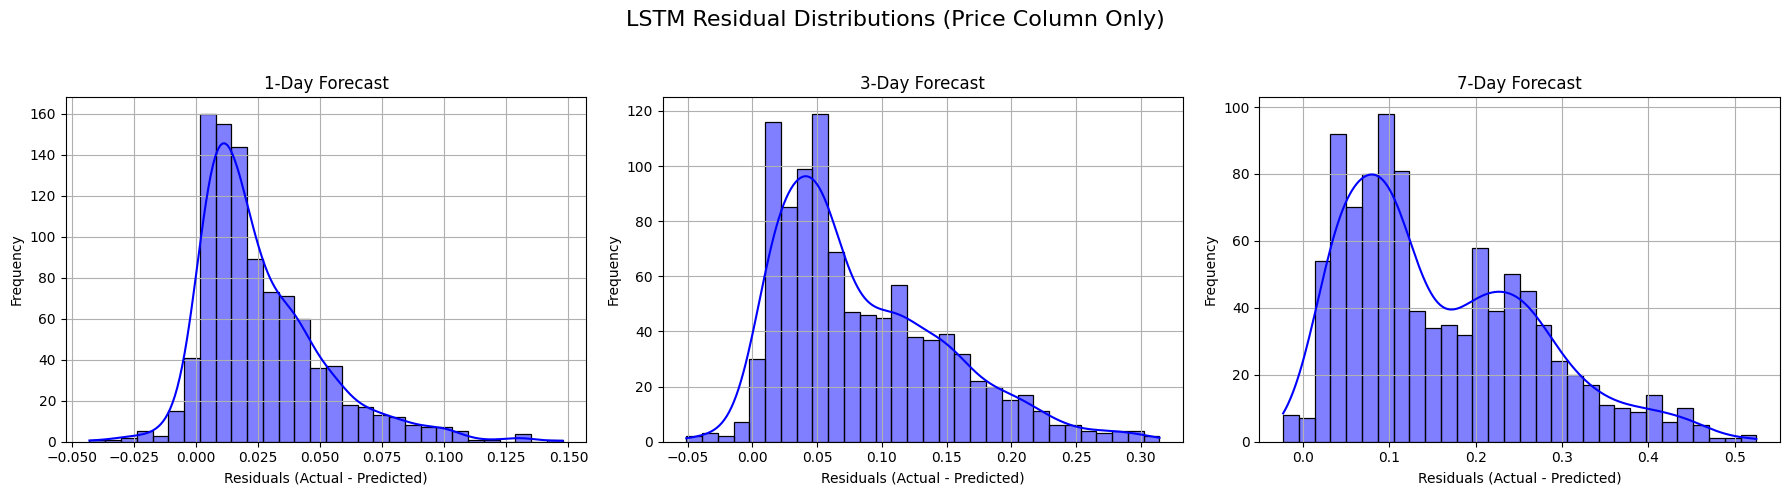

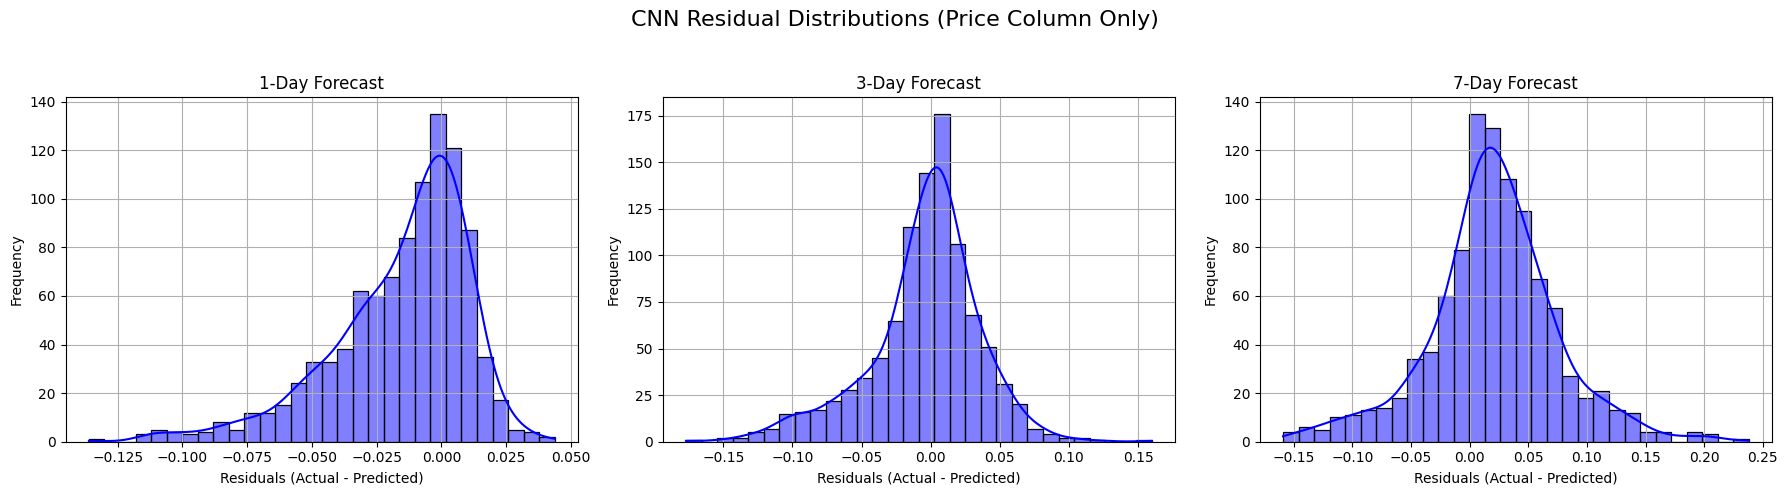

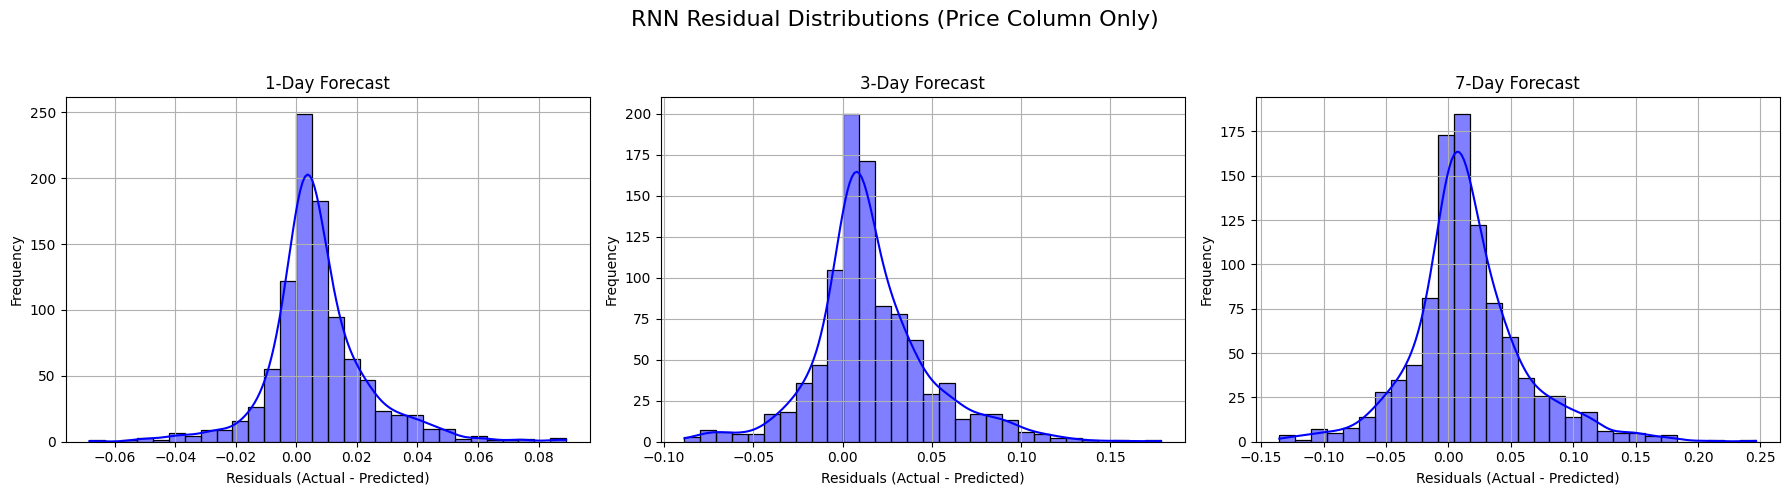

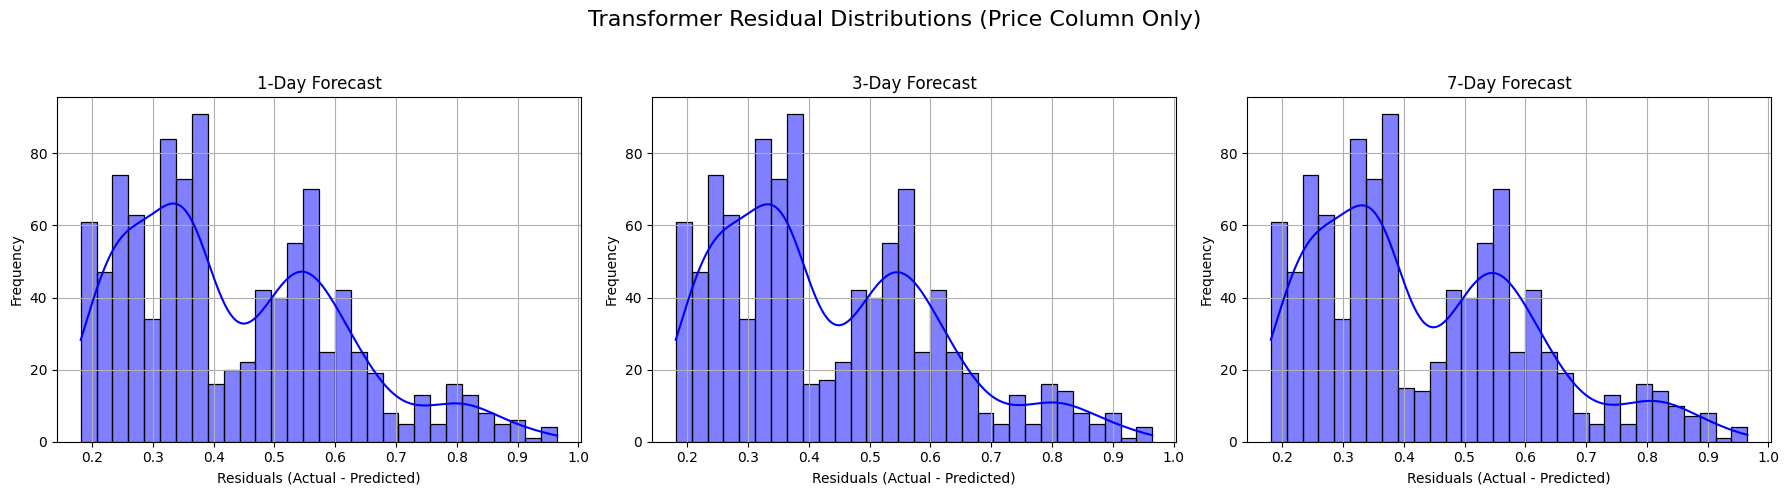

In [44]:
# Error Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate Residuals (Actual - Predicted)

# LSTM
residuals_lstm_1 = y_test[:,0,0] - y_pred_lstm[:,0,0]
residuals_lstm_3 = y_test[:,1,0] - y_pred_lstm[:,1,0]
residuals_lstm_7 = y_test[:,2,0] - y_pred_lstm[:,2,0]

# CNN
residuals_cnn_1 = y_test[:,0,0] - y_pred_cnn[:,0,0]
residuals_cnn_3 = y_test[:,1,0] - y_pred_cnn[:,1,0]
residuals_cnn_7 = y_test[:,2,0] - y_pred_cnn[:,2,0]

# RNN
residuals_rnn_1 = y_test[:,0,0] - y_pred_rnn[:,0,0]
residuals_rnn_3 = y_test[:,1,0] - y_pred_rnn[:,1,0]
residuals_rnn_7 = y_test[:,2,0] - y_pred_rnn[:,2,0]

# Transformer
residuals_transformer_1 = y_test[:,0,0] - y_pred_transformer[:,0,0]
residuals_transformer_3 = y_test[:,1,0] - y_pred_transformer[:,1,0]
residuals_transformer_7 = y_test[:,2,0] - y_pred_transformer[:,2,0]

# Step 2: Organize residuals
models_residuals = {
    "LSTM": [residuals_lstm_1, residuals_lstm_3, residuals_lstm_7],
    "CNN": [residuals_cnn_1, residuals_cnn_3, residuals_cnn_7],
    "RNN": [residuals_rnn_1, residuals_rnn_3, residuals_rnn_7],
    "Transformer": [residuals_transformer_1, residuals_transformer_3, residuals_transformer_7],
}

horizons = ["1-Day", "3-Day", "7-Day"]

# Side-by-side residual plots for each model
for model, residuals_list in models_residuals.items():
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{model} Residual Distributions (Price Column Only)", fontsize=16)
    
    for i, horizon in enumerate(horizons):
        sns.histplot(residuals_list[i], bins=30, kde=True, color="blue", ax=axes[i])
        axes[i].set_title(f"{horizon} Forecast")
        axes[i].set_xlabel("Residuals (Actual - Predicted)")
        axes[i].set_ylabel("Frequency")
        axes[i].grid(True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.show()


In [45]:
# statistics for residuals (Price column only)

def print_stats(name, res1, res3, res7):
    print(f"{name} 1-Day Residuals -> Mean: {res1.mean():.4f}, Std: {res1.std():.4f}")
    print(f"{name} 3-Day Residuals -> Mean: {res3.mean():.4f}, Std: {res3.std():.4f}")
    print(f"{name} 7-Day Residuals -> Mean: {res7.mean():.4f}, Std: {res7.std():.4f}\n")

# LSTM
print_stats("LSTM", residuals_lstm_1, residuals_lstm_3, residuals_lstm_7)

# CNN
print_stats("CNN", residuals_cnn_1, residuals_cnn_3, residuals_cnn_7)

# RNN
print_stats("RNN", residuals_rnn_1, residuals_rnn_3, residuals_rnn_7)

# Transformer
print_stats("Transformer", residuals_transformer_1, residuals_transformer_3, residuals_transformer_7)


LSTM 1-Day Residuals -> Mean: 0.0259, Std: 0.0246
LSTM 3-Day Residuals -> Mean: 0.0839, Std: 0.0646
LSTM 7-Day Residuals -> Mean: 0.1590, Std: 0.1097

CNN 1-Day Residuals -> Mean: -0.0158, Std: 0.0265
CNN 3-Day Residuals -> Mean: -0.0045, Std: 0.0404
CNN 7-Day Residuals -> Mean: 0.0199, Std: 0.0551

RNN 1-Day Residuals -> Mean: 0.0070, Std: 0.0164
RNN 3-Day Residuals -> Mean: 0.0163, Std: 0.0325
RNN 7-Day Residuals -> Mean: 0.0157, Std: 0.0451

Transformer 1-Day Residuals -> Mean: 0.4314, Std: 0.1740
Transformer 3-Day Residuals -> Mean: 0.4324, Std: 0.1757
Transformer 7-Day Residuals -> Mean: 0.4345, Std: 0.1778



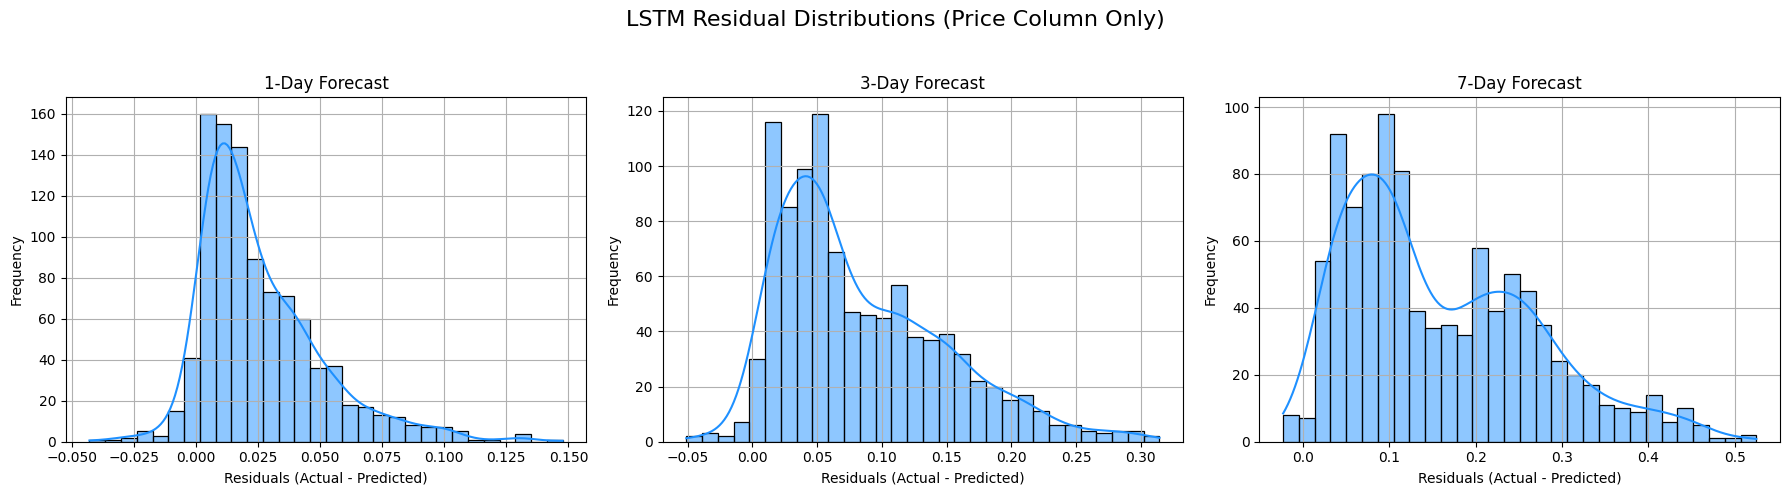

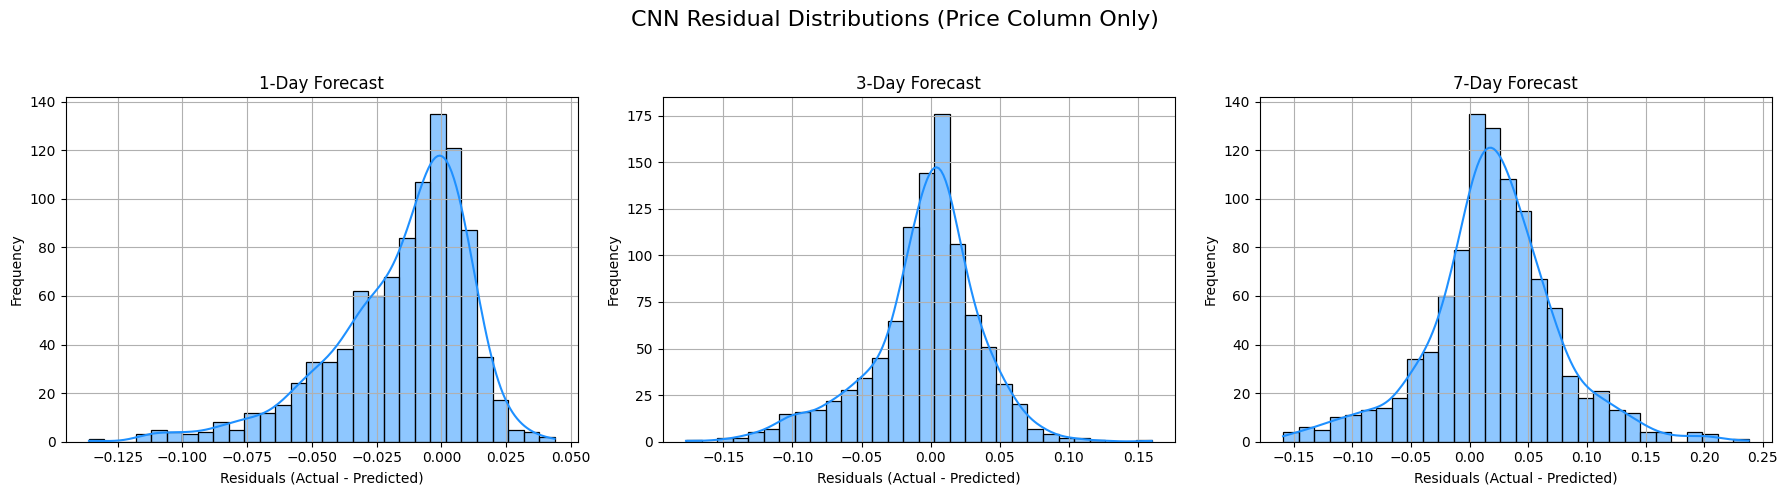

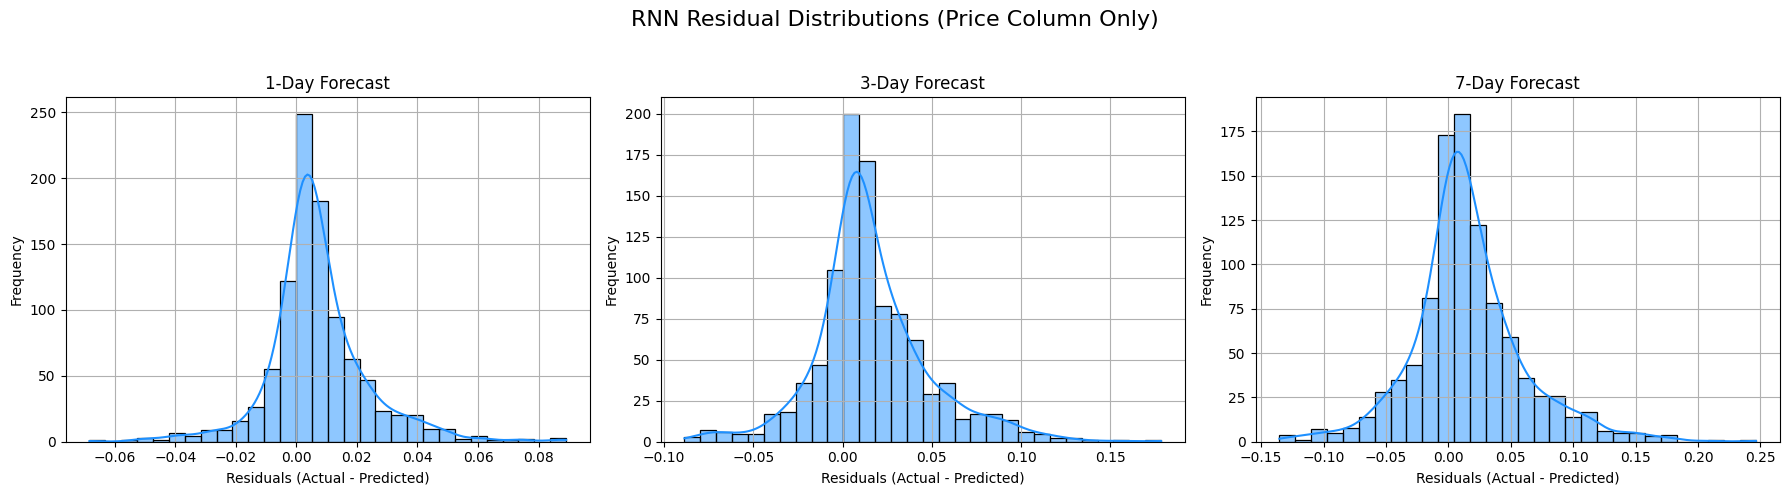

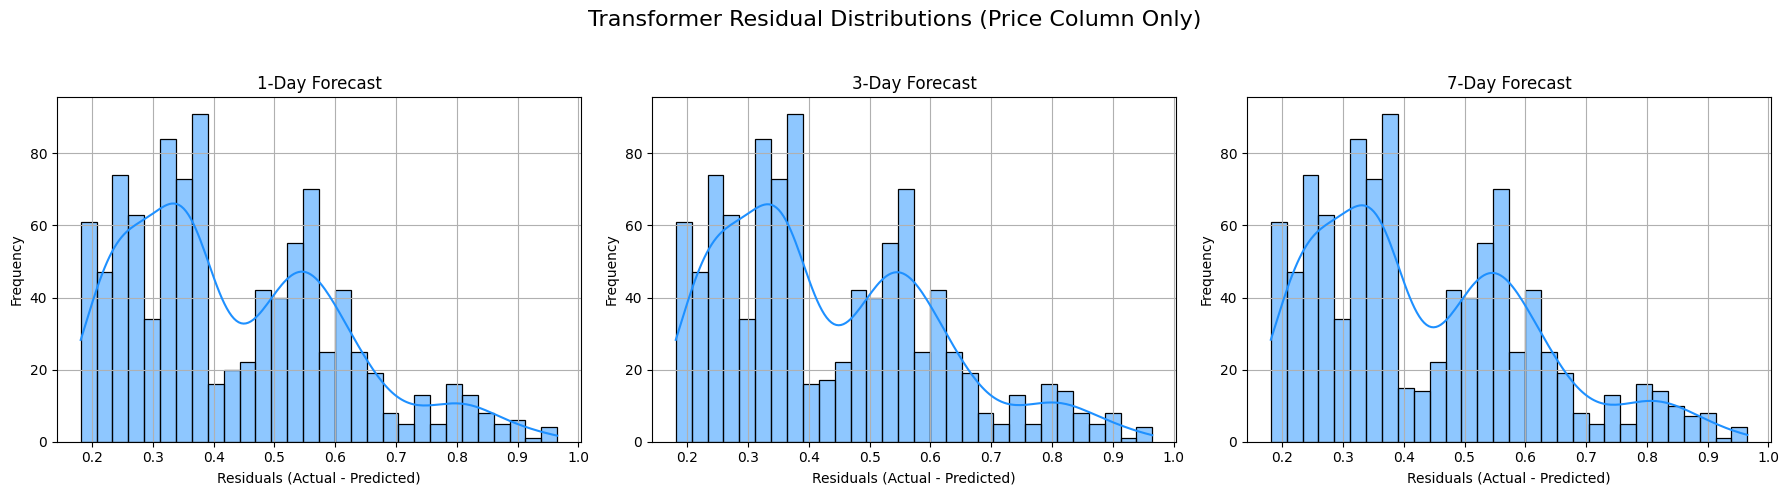

In [46]:
# RESIDUAL PLOTS

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate residuals (errors) for Price column only
residuals = {
    "LSTM": [
        y_test[:,0,0] - y_pred_lstm[:,0,0],   # 1-day
        y_test[:,1,0] - y_pred_lstm[:,1,0],   # 3-day
        y_test[:,2,0] - y_pred_lstm[:,2,0]    # 7-day
    ],
    "CNN": [
        y_test[:,0,0] - y_pred_cnn[:,0,0],
        y_test[:,1,0] - y_pred_cnn[:,1,0],
        y_test[:,2,0] - y_pred_cnn[:,2,0]
    ],
    "RNN": [
        y_test[:,0,0] - y_pred_rnn[:,0,0],
        y_test[:,1,0] - y_pred_rnn[:,1,0],
        y_test[:,2,0] - y_pred_rnn[:,2,0]
    ],
    "Transformer": [
        y_test[:,0,0] - y_pred_transformer[:,0,0],
        y_test[:,1,0] - y_pred_transformer[:,1,0],
        y_test[:,2,0] - y_pred_transformer[:,2,0]
    ]
}

# Step 2: Plot subplots side-by-side for each model
horizons = ["1-Day", "3-Day", "7-Day"]

for model_name, res_list in residuals.items():
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{model_name} Residual Distributions (Price Column Only)", fontsize=16)
    
    for i, res in enumerate(res_list):
        sns.histplot(res, bins=30, kde=True, ax=axes[i], color="dodgerblue")
        axes[i].set_title(f"{horizons[i]} Forecast")
        axes[i].set_xlabel("Residuals (Actual - Predicted)")
        axes[i].set_ylabel("Frequency")
        axes[i].grid(True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.show()


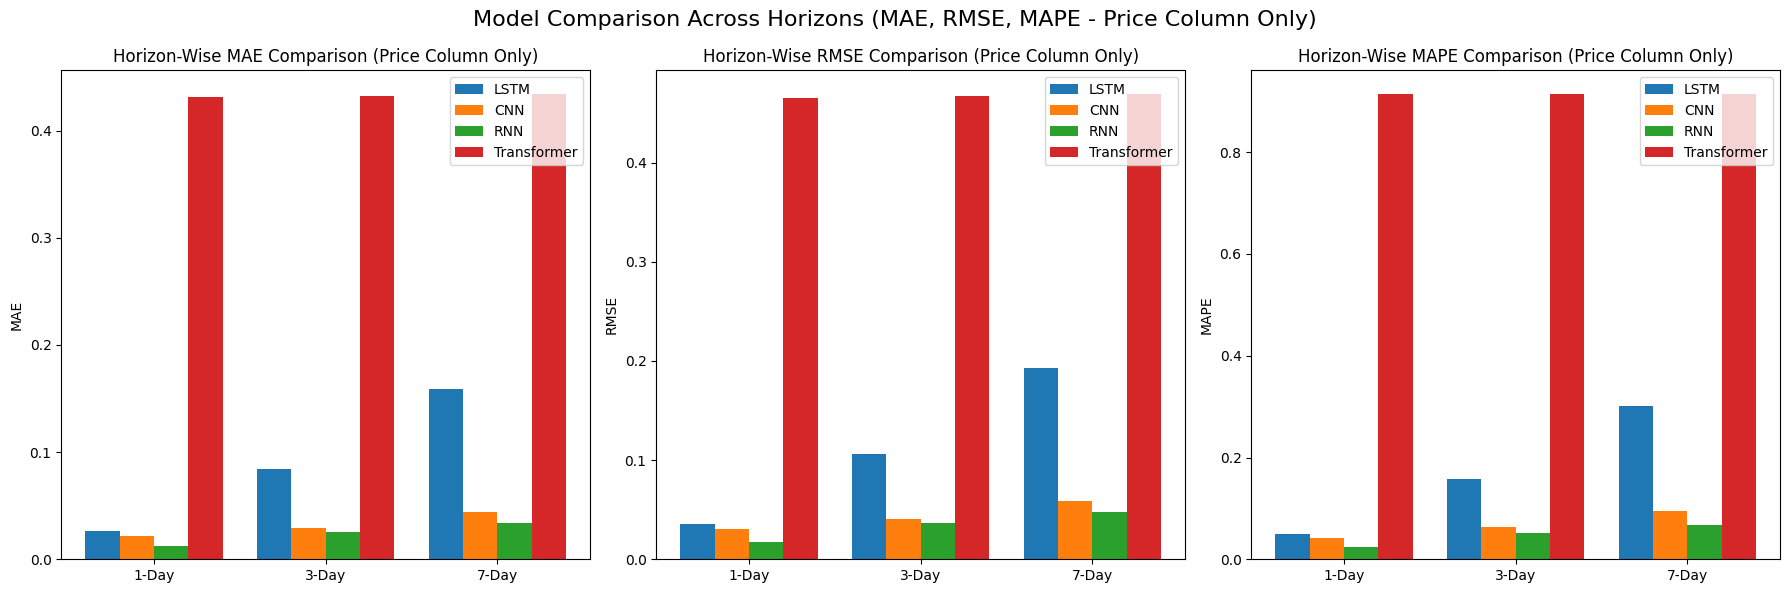

In [47]:
# Horizon wise comparision

import numpy as np
import matplotlib.pyplot as plt

# Horizons
horizons = ["1-Day", "3-Day", "7-Day"]
x = np.arange(len(horizons))
bar_width = 0.2

# Metric values for each model (Price column only)
mae_lstm = [mae_lstm_1, mae_lstm_3, mae_lstm_7]
mae_cnn = [mae_cnn_1, mae_cnn_3, mae_cnn_7]
mae_rnn = [mae_rnn_1, mae_rnn_3, mae_rnn_7]
mae_transformer = [mae_transformer_1, mae_transformer_3, mae_transformer_7]

rmse_lstm = [rmse_lstm_1, rmse_lstm_3, rmse_lstm_7]
rmse_cnn = [rmse_cnn_1, rmse_cnn_3, rmse_cnn_7]
rmse_rnn = [rmse_rnn_1, rmse_rnn_3, rmse_rnn_7]
rmse_transformer = [rmse_transformer_1, rmse_transformer_3, rmse_transformer_7]

mape_lstm = [mape_lstm_1, mape_lstm_3, mape_lstm_7]
mape_cnn = [mape_cnn_1, mape_cnn_3, mape_cnn_7]
mape_rnn = [mape_rnn_1, mape_rnn_3, mape_rnn_7]
mape_transformer = [mape_transformer_1, mape_transformer_3, mape_transformer_7]

# Create subplots: 3 columns (MAE, RMSE, MAPE)
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)

# --- MAE ---
axes[0].bar(x - 1.5*bar_width, mae_lstm, bar_width, label="LSTM")
axes[0].bar(x - 0.5*bar_width, mae_cnn, bar_width, label="CNN")
axes[0].bar(x + 0.5*bar_width, mae_rnn, bar_width, label="RNN")
axes[0].bar(x + 1.5*bar_width, mae_transformer, bar_width, label="Transformer")
axes[0].set_xticks(x)
axes[0].set_xticklabels(horizons)
axes[0].set_title("Horizon-Wise MAE Comparison (Price Column Only)")
axes[0].set_ylabel("MAE")
axes[0].legend()

# --- RMSE ---
axes[1].bar(x - 1.5*bar_width, rmse_lstm, bar_width, label="LSTM")
axes[1].bar(x - 0.5*bar_width, rmse_cnn, bar_width, label="CNN")
axes[1].bar(x + 0.5*bar_width, rmse_rnn, bar_width, label="RNN")
axes[1].bar(x + 1.5*bar_width, rmse_transformer, bar_width, label="Transformer")
axes[1].set_xticks(x)
axes[1].set_xticklabels(horizons)
axes[1].set_title("Horizon-Wise RMSE Comparison (Price Column Only)")
axes[1].set_ylabel("RMSE")
axes[1].legend()

# --- MAPE ---
axes[2].bar(x - 1.5*bar_width, mape_lstm, bar_width, label="LSTM")
axes[2].bar(x - 0.5*bar_width, mape_cnn, bar_width, label="CNN")
axes[2].bar(x + 0.5*bar_width, mape_rnn, bar_width, label="RNN")
axes[2].bar(x + 1.5*bar_width, mape_transformer, bar_width, label="Transformer")
axes[2].set_xticks(x)
axes[2].set_xticklabels(horizons)
axes[2].set_title("Horizon-Wise MAPE Comparison (Price Column Only)")
axes[2].set_ylabel("MAPE")
axes[2].legend()

plt.suptitle("Model Comparison Across Horizons (MAE, RMSE, MAPE - Price Column Only)", fontsize=16)
plt.tight_layout()
plt.show()


In [48]:
# Business Interpretation Section (Price Column Only)

def business_interpretation(df_results):
    print("### Business Interpretation (Price Column Only)\n")
    
    # 1-Day Horizon
    best_1d = df_results.loc[df_results["1-Day MAE"].idxmin(), "Model"]
    print(f"- **1-Day Forecasts**: {best_1d} achieved the lowest error on Price. This is most useful for **day traders** and platforms needing reliable short-term signals.")
    
    # 3-Day Horizon
    best_3d = df_results.loc[df_results["3-Day MAE"].idxmin(), "Model"]
    print(f"- **3-Day Forecasts**: {best_3d} performed best on Price. This horizon supports **algorithmic trading systems** and **mid-term investment strategies**.")
    
    # 7-Day Horizon
    best_7d = df_results.loc[df_results["7-Day MAE"].idxmin(), "Model"]
    print(f"- **7-Day Forecasts**: {best_7d} was strongest on Price. This is valuable for **risk managers** anticipating weekly volatility and **investment dashboards** providing predictive insights.")
    
    print("\nOverall, the comparison highlights how different architectures excel at different horizons (Price column only):")
    print("- CNN → short-term trend detection")
    print("- RNN → baseline sequential learning")
    print("- LSTM → long-term dependency capture")
    print("- Transformer → global context awareness")
    print("\nThis ensures a **multi-horizon forecasting system** tailored to diverse business needs, all focused on Price predictions.")

# Run interpretation
business_interpretation(df_results)


### Business Interpretation (Price Column Only)

- **1-Day Forecasts**: RNN achieved the lowest error on Price. This is most useful for **day traders** and platforms needing reliable short-term signals.
- **3-Day Forecasts**: RNN performed best on Price. This horizon supports **algorithmic trading systems** and **mid-term investment strategies**.
- **7-Day Forecasts**: RNN was strongest on Price. This is valuable for **risk managers** anticipating weekly volatility and **investment dashboards** providing predictive insights.

Overall, the comparison highlights how different architectures excel at different horizons (Price column only):
- CNN → short-term trend detection
- RNN → baseline sequential learning
- LSTM → long-term dependency capture
- Transformer → global context awareness

This ensures a **multi-horizon forecasting system** tailored to diverse business needs, all focused on Price predictions.


e:\vscode\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 29, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,675 (580.76 KB)

 Trainable params: 148,675 (580.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 3.0398e-04 - val_loss: 0.0102
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.7165e-04 - val_loss: 0.0108
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.3760e-04 - val_loss: 0.0128
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.2682e-04 - val_loss: 0.0170
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 1.0983e-04 - val_loss: 0.0203
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 1.1819e-04 - val_loss: 0.0136
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.0894e-04 - val_loss: 0.0085
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.0161e-04 - val_loss: 0.0099
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.0465e-04 - val_loss: 0.0105
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 1.0048e-04 - val_loss: 0.0187
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 1.0462e-04 - val_loss: 0.01

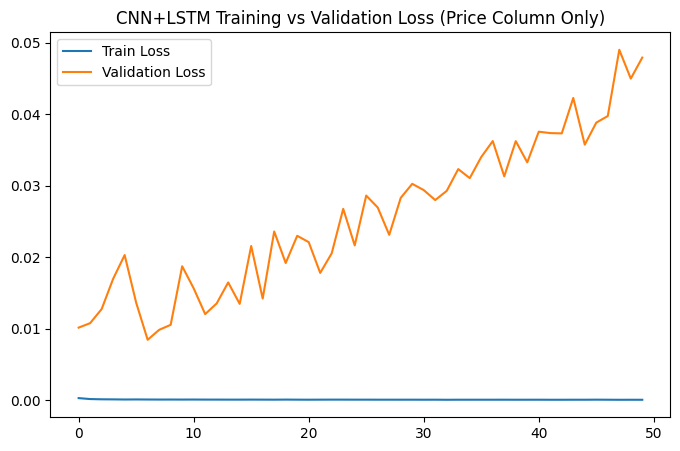

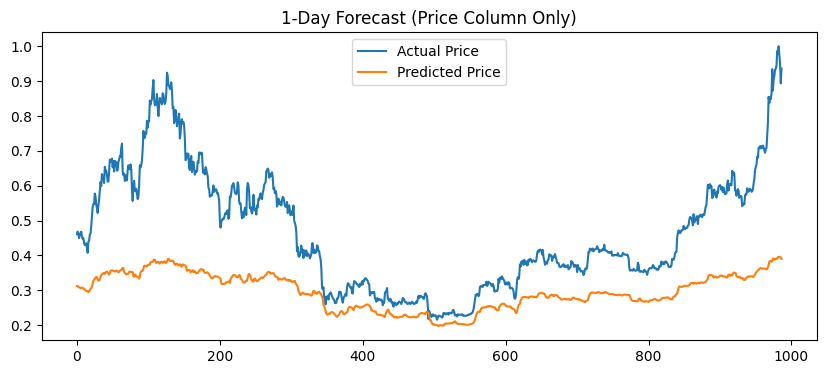

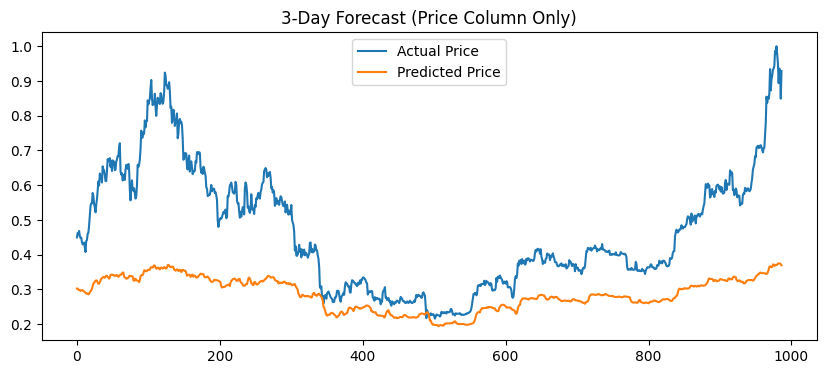

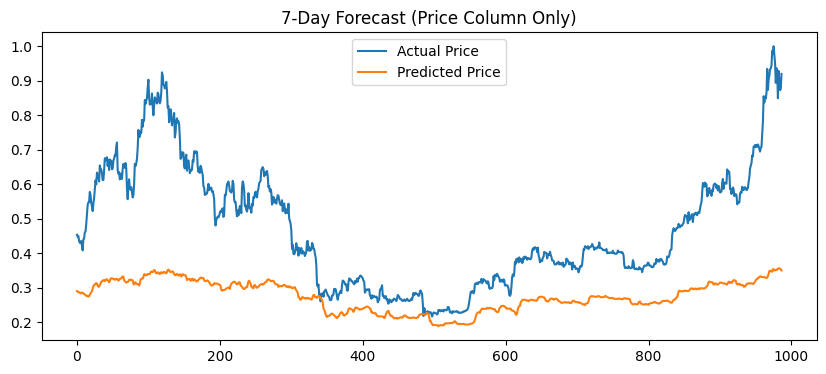

In [49]:
# CNN + Multi‑Layer LSTM hybrid model

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Reshape, Dropout

# 1. Define sequence length
seq_length = 60

# 2. Train-test split (assuming X, y already created with only Price column)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 3. Build CNN + Multi-Layer LSTM (Price column only)
cnn_lstm_model = Sequential()

# CNN feature extractor
cnn_lstm_model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                          input_shape=(seq_length, 1)))   # only Price column
cnn_lstm_model.add(MaxPooling1D(pool_size=2))
cnn_lstm_model.add(Dropout(0.2))

# Stacked LSTMs
cnn_lstm_model.add(LSTM(128, return_sequences=True))
cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(LSTM(64, return_sequences=False))
cnn_lstm_model.add(Dropout(0.2))

# Dense output for multi-horizon predictions (3 horizons × 1 feature)
cnn_lstm_model.add(Dense(3 * 1))
cnn_lstm_model.add(Reshape((3, 1)))

cnn_lstm_model.compile(loss="mean_squared_error", optimizer="adam")
cnn_lstm_model.summary()

# 4. Train model
history_cnn_lstm = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1,
    validation_split=0.1
)

# 5. Predict
y_pred_cnn_lstm = cnn_lstm_model.predict(X_test)

# 6. Evaluate horizon-wise metrics (Price column only)
def evaluate_horizon(y_true, y_pred, horizon_idx):
    mae = mean_absolute_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0])
    rmse = np.sqrt(mean_squared_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0]))
    mape = mean_absolute_percentage_error(y_true[:,horizon_idx,0], y_pred[:,horizon_idx,0])
    return mae, rmse, mape

for horizon, idx in zip(["1-Day", "3-Day", "7-Day"], [0,1,2]):
    mae, rmse, mape = evaluate_horizon(y_test, y_pred_cnn_lstm, idx)
    print(f"CNN+LSTM {horizon} (Price) -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")

# 7. Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn_lstm.history['loss'], label='Train Loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN+LSTM Training vs Validation Loss (Price Column Only)")
plt.show()

# 8. Plot actual vs predicted for each horizon
horizons = ["1-Day", "3-Day", "7-Day"]
for idx, horizon in enumerate(horizons):
    plt.figure(figsize=(10,4))
    plt.plot(y_test[:,idx,0], label="Actual Price")
    plt.plot(y_pred_cnn_lstm[:,idx,0], label="Predicted Price")
    plt.title(f"{horizon} Forecast (Price Column Only)")
    plt.legend()
    plt.show()
